In [21]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
#Loading the dataset
df = pd.read_csv('ecommerce_bigdata.csv')

In [4]:
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [15]:
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


In [8]:
df.columns

Index(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType',
       'Sales', 'Profit'],
      dtype='str')

In [11]:
missing_values = df.isnull().sum()
print(missing_values)

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64


In [13]:
empty_rows = df[df.isnull().any(axis=1)]
print(empty_rows)

Empty DataFrame
Columns: [TransactionID, Date, Region, ProductCategory, CustomerType, Sales, Profit]
Index: []


In [14]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [TransactionID, Date, Region, ProductCategory, CustomerType, Sales, Profit]
Index: []


In [16]:
# Data visualization
plt.style.use('seaborn-v0_8')

Text(0, 0.5, 'Frequency')

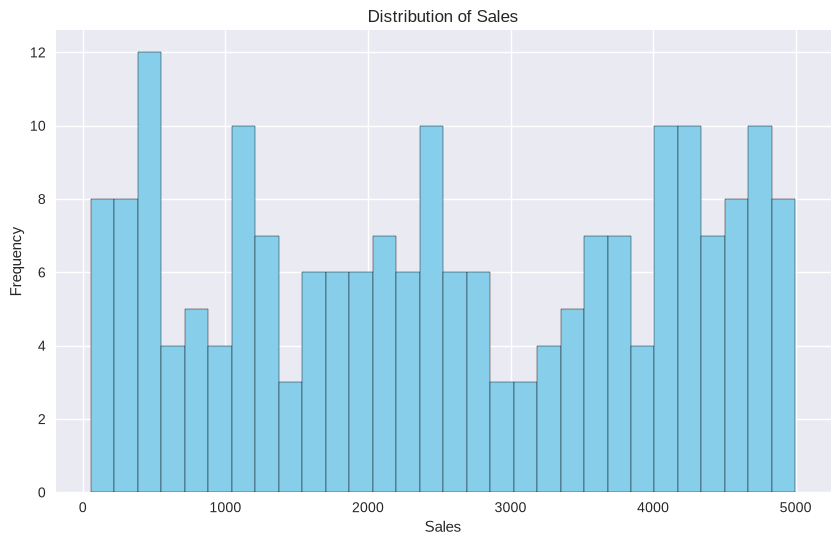

In [19]:
# Distribution of sales
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

Text(0, 0.5, 'Profit')

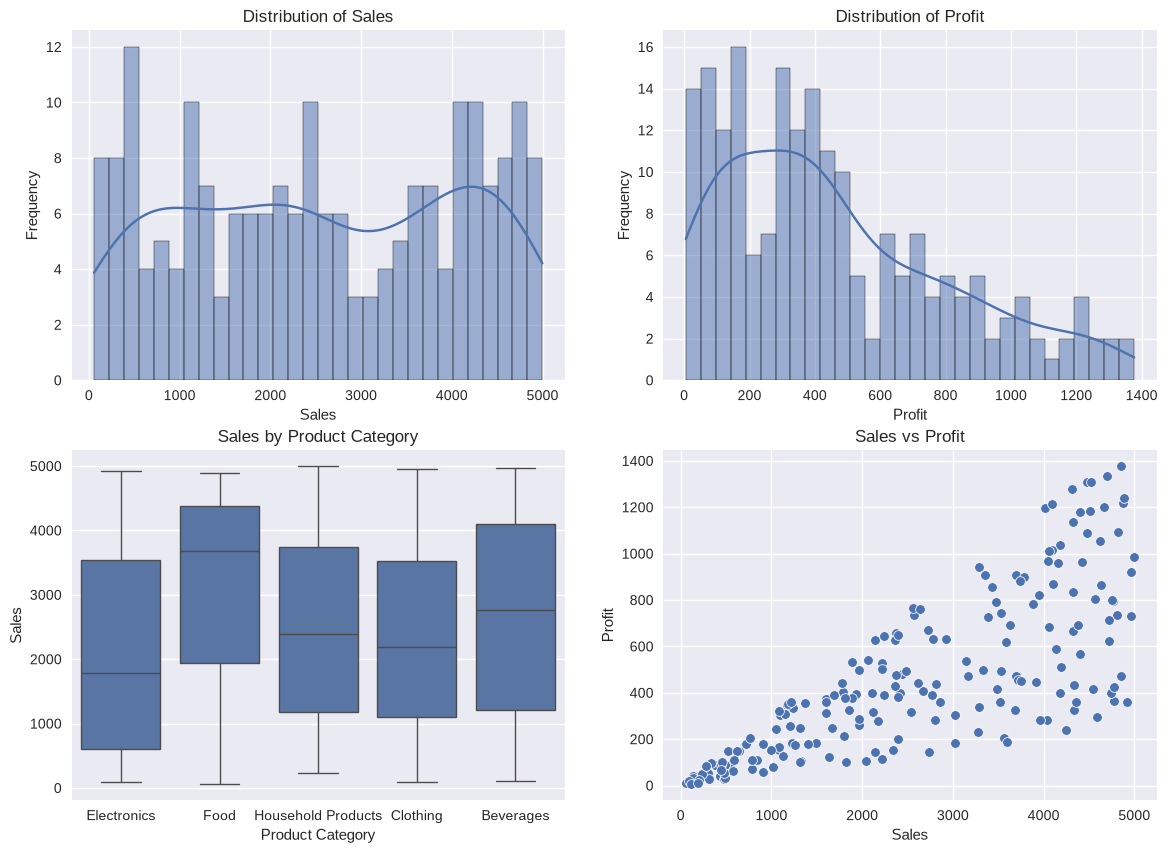

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 Plot Distribution of Sales
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sales')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')
# 2 Plot Distribution of Profit

sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

# Sales by product category (using boxplot to show distribution)
sns.boxplot(x='ProductCategory', y='Sales', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Sales by Product Category')
axes[1, 0].set_xlabel('Product Category')
axes[1, 0].set_ylabel('Sales')

# Relationship between Sales and Profit
sns.scatterplot(x='Sales', y='Profit', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Sales vs Profit')
axes[1, 1].set_xlabel('Sales')
axes[1, 1].set_ylabel('Profit')

In [27]:
# Copying the dataset for preprocessing
df_copy = df.copy()

In [28]:
# Extracting the date features
df_copy['Date'] = pd.to_datetime(df_copy['Date'])
df_copy['Month'] = df_copy['Date'].dt.month
df_copy['Day'] = df_copy['Date'].dt.day
df_copy['Weekday'] = df_copy['Date'].dt.weekday